In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [2]:
import os
!pip install dagshub mlflow -q
from kaggle_secrets import UserSecretsClient
os.environ["DAGSHUB_USER_TOKEN"] = UserSecretsClient().get_secret("DAGSHUB_TOKEN")

import dagshub
dagshub.init(repo_owner='lkhiz23', repo_name='IEEE-CIS-Fraud-Detection', mlflow=True)

import mlflow
print("Connected ✓")

Accessing as lkhiz23

Initialized MLflow to track repo "lkhiz23/IEEE-CIS-Fraud-Detection"

Repository lkhiz23/IEEE-CIS-Fraud-Detection initialized!

Connected ✓


# Model Experiment - Logistic Regression

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PATH = '/kaggle/input/competitions/ieee-fraud-detection/'

train_tx = pd.read_csv(PATH + 'train_transaction.csv')
train_id = pd.read_csv(PATH + 'train_identity.csv')
test_tx  = pd.read_csv(PATH + 'test_transaction.csv')
test_id  = pd.read_csv(PATH + 'test_identity.csv')

train = train_tx.merge(train_id, on='TransactionID', how='left')
test  = test_tx.merge(test_id,  on='TransactionID', how='left')

print("Train shape:", train.shape)
print("Test shape: ", test.shape)
train.head()

Train shape: (590540, 434)
Test shape:  (506691, 433)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [4]:
from sklearn.model_selection import train_test_split

X = train.drop(columns=['isFraud', 'TransactionID'])
y = train['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Fraud rate in train: {y_train.mean():.4f}")
print(f"Fraud rate in test:  {y_test.mean():.4f}")

X_train: (472432, 432)
X_test:  (118108, 432)
Fraud rate in train: 0.0350
Fraud rate in test:  0.0350


## Data Cleaning

In [10]:
with mlflow.start_run(run_name="LogisticRegression_Cleaning"):
    
    # - drop >80% missing cols, calculated on train only -
    missing = X_train.isnull().mean()
    drop_cols = missing[missing > 0.8].index.tolist()
    
    X_train = X_train.drop(columns=drop_cols)
    X_test  = X_test.drop(columns=drop_cols)
    
    print(f"Dropped: {len(drop_cols)} columns")
    print(f"Remaining: {X_train.shape[1]} features")
    
    mlflow.log_param("missing_threshold", 0.8)
    mlflow.log_param("dropped_cols", len(drop_cols))
    mlflow.log_param("remaining_features", X_train.shape[1])

Dropped: 74 columns
Remaining: 358 features
🏃 View run LogisticRegression_Cleaning at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/72222e51c2de4708be4d2ea22045b8ac
🧪 View experiment at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0


## Feature Engineering

In [11]:
with mlflow.start_run(run_name="LogisticRegression_Feature_Engineering"):
    
    def feature_engineering(df):
        df = df.copy()
        # - time features -
        df['hour']  = (df['TransactionDT'] // 3600) % 24
        df['day']   = (df['TransactionDT'] // (3600 * 24)) % 7
        df['month'] = (df['TransactionDT'] // (3600 * 24 * 30)) % 12
        # - transaction amount -
        df['log_TransactionAmt'] = np.log1p(df['TransactionAmt'])
        df['cents'] = df['TransactionAmt'] - np.floor(df['TransactionAmt'])
        # - card uid -
        df['uid']  = df['card1'].astype(str) + '_' + df['card2'].astype(str)
        df['uid2'] = df['uid'] + '_' + df['card3'].astype(str)
        # - email features -
        df['email_match']   = (df['P_emaildomain'] == df['R_emaildomain']).astype(int)
        df['P_email_count'] = df['P_emaildomain'].map(df['P_emaildomain'].value_counts())
        df['R_email_count'] = df['R_emaildomain'].map(df['R_emaildomain'].value_counts())
        # - frequency encoding -
        df['card1_count'] = df['card1'].map(df['card1'].value_counts())
        df['uid_count']   = df['uid'].map(df['uid'].value_counts())
        # - os and browser -
        if 'id_30' in df.columns:
            df['OS'] = df['id_30'].str.extract(r'^([a-zA-Z\s]+)')
        if 'id_31' in df.columns:
            df['browser'] = df['id_31'].str.extract(r'^([a-zA-Z\s]+)')
        return df
    
    X_train = feature_engineering(X_train)
    X_test  = feature_engineering(X_test)
    
    print(f"Shape after FE: {X_train.shape}")
    mlflow.log_param("added_features", ['hour','day','month','log_TransactionAmt',
                                        'cents','uid','uid2','email_match',
                                        'P_email_count','R_email_count',
                                        'card1_count','uid_count','OS','browser'])
    mlflow.log_param("total_features", X_train.shape[1])

Shape after FE: (472432, 371)
🏃 View run LogisticRegression_Feature_Engineering at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/e280157887f04e77bdc26b501a659d94
🧪 View experiment at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0


## Encoding and Imputation

In [12]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

with mlflow.start_run(run_name="LogisticRegression_Encoding"):
    
    # - label encode all categorical cols -
    # encode train and test together to avoid unseen category crashes
    cat_cols = X_train.select_dtypes(include='object').columns.tolist()
    
    for col in cat_cols:
        le = LabelEncoder()
        combined = pd.concat([X_train[col], X_test[col]], axis=0).astype(str)
        le.fit(combined)
        X_train[col] = le.transform(X_train[col].astype(str))
        X_test[col]  = le.transform(X_test[col].astype(str))
    
    print(f"Label encoded {len(cat_cols)} categorical columns")
    
    # - impute missing with median, fit on train only -
    imputer = SimpleImputer(strategy='median')
    X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
    X_test  = pd.DataFrame(imputer.transform(X_test),      columns=X_test.columns)
    
    print("Imputed with median")
    
    # - scale, fit on train only -
    scaler = StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
    X_test  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns)
    
    print(f"Scaled. Final shape: {X_train.shape}")
    
    mlflow.log_param("encoding", "LabelEncoder")
    mlflow.log_param("imputation", "median")
    mlflow.log_param("scaling", "StandardScaler")

Label encoded 29 categorical columns
Imputed with median
Scaled. Final shape: (472432, 371)
🏃 View run LogisticRegression_Encoding at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/da216775763448d2a1a31d0ac50aa55a
🧪 View experiment at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0


## Feature Selection

In [13]:
from sklearn.feature_selection import SelectKBest, f_classif

with mlflow.start_run(run_name="LogisticRegression_Feature_Selection"):
    
    # - method 1: correlation filter -
    # remove features with very low correlation to target
    correlations = pd.Series(
        np.abs(np.corrcoef(X_train.T, y_train)[-1, :-1]),
        index=X_train.columns
    )
    low_corr_cols = correlations[correlations < 0.005].index.tolist()
    
    X_train_fs = X_train.drop(columns=low_corr_cols)
    X_test_fs  = X_test.drop(columns=low_corr_cols)
    
    print(f"Correlation filter removed: {len(low_corr_cols)} features")
    print(f"Remaining after correlation filter: {X_train_fs.shape[1]}")
    
    # - method 2: SelectKBest -
    k = 100
    selector = SelectKBest(f_classif, k=k)
    X_train_fs = pd.DataFrame(
        selector.fit_transform(X_train_fs, y_train),
        columns=X_train_fs.columns[selector.get_support()]
    )
    X_test_fs = pd.DataFrame(
        selector.transform(X_test_fs),
        columns=X_train_fs.columns
    )
    
    print(f"SelectKBest kept top {k} features")
    print(f"Final shape: {X_train_fs.shape}")
    
    mlflow.log_param("corr_threshold", 0.005)
    mlflow.log_param("corr_removed", len(low_corr_cols))
    mlflow.log_param("selectkbest_k", k)
    mlflow.log_metric("final_features", X_train_fs.shape[1])

Correlation filter removed: 73 features
Remaining after correlation filter: 298
SelectKBest kept top 100 features
Final shape: (472432, 100)
🏃 View run LogisticRegression_Feature_Selection at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/0b67c1a908f1479aa8ff5f4f73d09be7
🧪 View experiment at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0


## Training

CV AUC scores: [0.7913 0.7875 0.7898 0.7923 0.7936]
CV AUC mean:   0.7909
CV AUC std:    0.0021

=== Test Set Results ===
AUC-ROC:   0.7903
F1:        0.2572
Precision: 0.1669
Recall:    0.5604

              precision    recall  f1-score   support

           0       0.98      0.90      0.94    113975
           1       0.17      0.56      0.26      4133

    accuracy                           0.89    118108
   macro avg       0.57      0.73      0.60    118108
weighted avg       0.95      0.89      0.91    118108



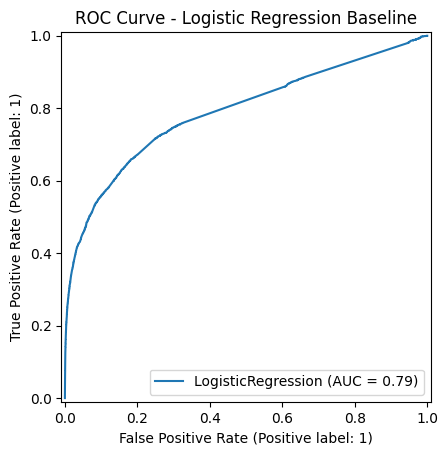

🏃 View run LogisticRegression_Baseline at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/4d60c42aca174644aa88d43363e8a1d6
🧪 View experiment at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, f1_score, precision_score, 
                              recall_score, classification_report, RocCurveDisplay)
from sklearn.model_selection import StratifiedKFold, cross_val_score

with mlflow.start_run(run_name="LogisticRegression_Baseline"):
    
    model = LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'  # handles imbalance
    )
    
    # - cross validation on train -
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train_fs, y_train, cv=cv, scoring='roc_auc')
    
    print(f"CV AUC scores: {cv_scores.round(4)}")
    print(f"CV AUC mean:   {cv_scores.mean():.4f}")
    print(f"CV AUC std:    {cv_scores.std():.4f}")
    
    # - train on full train set -
    model.fit(X_train_fs, y_train)
    
    # - evaluate on test set -
    y_pred       = model.predict(X_test_fs)
    y_pred_proba = model.predict_proba(X_test_fs)[:, 1]
    
    auc       = roc_auc_score(y_test, y_pred_proba)
    f1        = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    
    print(f"\n=== Test Set Results ===")
    print(f"AUC-ROC:   {auc:.4f}")
    print(f"F1:        {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"\n{classification_report(y_test, y_pred)}")
    
    # - ROC curve -
    RocCurveDisplay.from_estimator(model, X_test_fs, y_test)
    plt.title('ROC Curve - Logistic Regression Baseline')
    plt.savefig('/kaggle/working/lr_roc_baseline.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # - log to mlflow -
    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("max_iter", 1000)
    mlflow.log_metric("cv_auc_mean", cv_scores.mean())
    mlflow.log_metric("cv_auc_std", cv_scores.std())
    mlflow.log_metric("test_auc", auc)
    mlflow.log_metric("test_f1", f1)
    mlflow.log_metric("test_precision", precision)
    mlflow.log_metric("test_recall", recall)
    mlflow.log_artifact('/kaggle/working/lr_roc_baseline.png')

In [15]:
for C in [0.1, 1, 10]:
    with mlflow.start_run(run_name=f"LogisticRegression_C{C}"):
        model = LogisticRegression(
            C=C,
            max_iter=1000,
            random_state=42,
            class_weight='balanced'
        )
        model.fit(X_train_fs, y_train)
        y_pred_proba = model.predict_proba(X_test_fs)[:, 1]
        y_pred       = model.predict(X_test_fs)
        auc       = roc_auc_score(y_test, y_pred_proba)
        f1        = f1_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall    = recall_score(y_test, y_pred)
        print(f"C={C} | AUC: {auc:.4f} F1: {f1:.4f} Precision: {precision:.4f} Recall: {recall:.4f}")
        mlflow.log_params({"C": C, "class_weight": "balanced"})
        mlflow.log_metrics({"test_auc": auc, "test_f1": f1, "test_precision": precision, "test_recall": recall})

C=0.1 | AUC: 0.7902 F1: 0.2562 Precision: 0.1660 Recall: 0.5609
🏃 View run LogisticRegression_C0.1 at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/00442624101d41f0b96c3534f81cd2a2
🧪 View experiment at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0
C=1 | AUC: 0.7903 F1: 0.2572 Precision: 0.1669 Recall: 0.5604
🏃 View run LogisticRegression_C1 at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/5f1f4adafe9b4538b64e9b6b75ec91ff
🧪 View experiment at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0
C=10 | AUC: 0.7903 F1: 0.2561 Precision: 0.1660 Recall: 0.5609
🏃 View run LogisticRegression_C10 at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/980c1a24e9dc467587e9453d3be468a9
🧪 View experiment at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0


In [16]:
with mlflow.start_run(run_name="LogisticRegression_Best_Pipeline"):
    
    best_model = LogisticRegression(
        C=1,
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    )
    best_model.fit(X_train_fs, y_train)
    y_pred_proba = best_model.predict_proba(X_test_fs)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)
    
    mlflow.log_params({"C": 1, "class_weight": "balanced", "max_iter": 1000})
    mlflow.log_metric("test_auc", auc)
    
    mlflow.sklearn.log_model(
        best_model,
        "logistic_regression_model",
        registered_model_name="LogisticRegression_Fraud"
    )
    
    print(f"Best model AUC: {auc:.4f}")
    print("Model saved to MLflow")

2026/05/02 19:30:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/02 19:30:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'LogisticRegression_Fraud'.
2026/05/02 19:30:39 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: LogisticRegression_Fraud, version 1
Created version '1' of model 'LogisticRegression_Fraud'.


Best model AUC: 0.7903
Model saved to MLflow
🏃 View run LogisticRegression_Best_Pipeline at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0/runs/a5308e23d5c84507a726f9a78a6d2875
🧪 View experiment at: https://dagshub.com/lkhiz23/IEEE-CIS-Fraud-Detection.mlflow/#/experiments/0
